### Step 1: Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [20]:
import cv2
import os
import numpy as np
import imutils
import matplotlib.pyplot as plt

In [3]:
from skimage.filters import threshold_local
from skimage import measure

In [4]:
import tensorflow as tf

### Step 2: Function

In [6]:
def sort_contours(character_contours):
    boundingBoxes = [cv2.boundingRect(c) for c in character_contours]
    character_contours, boundingBoxes = zip(
        *sorted(
            zip(
                character_contours,
                boundingBoxes
            ),
            key=lambda b: b[1][0],
            reverse=False
        )
    )
    return character_contours

In [15]:
def segment_chars(plate_img, fixed_width):
    V = cv2.split(cv2.cvtColor(plate_img, cv2.COLOR_BGR2HSV))[2]

    thresh = cv2.adaptiveThreshold(
        V,
        255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY,
        11, 
        2
    )
  
    thresh = cv2.bitwise_not(thresh)

    plate_img = imutils.resize(plate_img, width = fixed_width)
    thresh = imutils.resize(thresh, width = fixed_width)
    bgr_thresh = cv2.cvtColor(thresh, cv2.COLOR_GRAY2BGR)
    labels = measure.label(thresh, background = 0)
 
    charCandidates = np.zeros(thresh.shape, dtype ='uint8')
 
    characters = []
    for label in np.unique(labels):
        if label == 0:
            continue
            
        labelMask = np.zeros(thresh.shape, dtype ='uint8')
        labelMask[labels == label] = 255
 
        cnts = cv2.findContours(
            labelMask,
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_SIMPLE
        )

        cnts = cnts[1] if imutils.is_cv3() else cnts[0]
 
        if len(cnts) > 0:
            c = max(cnts, key = cv2.contourArea)
            (boxX, boxY, boxW, boxH) = cv2.boundingRect(c)

            aspectRatio = boxW / float(boxH)
            solidity = cv2.contourArea(c) / float(boxW * boxH)
            heightRatio = boxH / float(plate_img.shape[0])

            # 筛选条件
            keepAspectRatio = aspectRatio < 1.0
            keepSolidity = solidity > 0.15
            keepHeight = heightRatio > 0.5 and heightRatio < 0.95

            if keepAspectRatio and keepSolidity and keepHeight and boxW > 14:
                hull = cv2.convexHull(c)
                cv2.drawContours(charCandidates, [hull], -1, 255, -1)
 
    contours, hier = cv2.findContours(
        charCandidates,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )
     
    if contours:
        contours = sort_contours(contours)
        addPixel = 4 
        for c in contours:
            (x, y, w, h) = cv2.boundingRect(c)
            if y > addPixel:
                y = y - addPixel
            else:
                y = 0
            if x > addPixel:
                x = x - addPixel
            else:
                x = 0
            temp = bgr_thresh[
                y:y + h + (addPixel * 2),
                x:x + w + (addPixel * 2)
                ]
            characters.append(temp)
        return characters
    else:
        return None

### Step 3: Class

In [8]:
class PlateFinder:
    def __init__(self, minPlateArea, maxPlateArea):
        self.min_area = minPlateArea
        self.max_area = maxPlateArea 
        self.element_structure = cv2.getStructuringElement(
            shape = cv2.MORPH_RECT, 
            ksize =(22, 3)
        )
 
    def preprocess(self, input_img):
        imgBlurred = cv2.GaussianBlur(input_img, (7, 7), 0)
        gray = cv2.cvtColor(imgBlurred, cv2.COLOR_BGR2GRAY)
         
        # sobelX to get the vertical edges
        sobelx = cv2.Sobel(gray, cv2.CV_8U, 1, 0, ksize=3) 
         
        # otsu's thresholding
        ret2, threshold_img = cv2.threshold(
            sobelx, 
            0, 
            255,
            cv2.THRESH_BINARY + cv2.THRESH_OTSU
        )
 
        morph_n_thresholded_img = threshold_img.copy()
        cv2.morphologyEx(
            src = threshold_img,
            op = cv2.MORPH_CLOSE,
            kernel = self.element_structure,
            dst = morph_n_thresholded_img
        )
        return morph_n_thresholded_img
 
    def extract_contours(self, after_preprocess):
        contours, _ = cv2.findContours(
            after_preprocess,
            mode = cv2.RETR_EXTERNAL,
            method = cv2.CHAIN_APPROX_NONE
        )
        return contours
 
    def clean_plate(self, plate):
        gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)
        thresh = cv2.adaptiveThreshold(
            gray,
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            11, 
            2
        )
         
        contours, _ = cv2.findContours(
            thresh.copy(),
            cv2.RETR_EXTERNAL,
            cv2.CHAIN_APPROX_NONE
        )
 
        if contours:
            areas = [cv2.contourArea(c) for c in contours]
            max_index = np.argmax(areas) 
            max_cnt = contours[max_index]
            max_cntArea = areas[max_index]
            x, y, w, h = cv2.boundingRect(max_cnt)
            rect = cv2.minAreaRect(max_cnt)
            if not self.ratioCheck(max_cntArea, plate.shape[1], plate.shape[0]):
                return plate, False, None
            return plate, True, [x, y, w, h]
        else:
            return plate, False, None

    def find_characters_on_plate(self, plate):
        charactersFound = segment_chars(plate, 400)
        if charactersFound:
            return charactersFound
            
    def check_plate(self, input_img, contour):
        min_rect = cv2.minAreaRect(contour)
        if self.validateRatio(min_rect):
            x, y, w, h = cv2.boundingRect(contour)
            after_validation_img = input_img[y:y + h, x:x + w]
            after_clean_plate_img, plateFound, coordinates = self.clean_plate(after_validation_img)
            
            if plateFound:
                characters_on_plate = self.find_characters_on_plate(after_clean_plate_img)
                
                if (characters_on_plate is not None and len(characters_on_plate) == 8):
                    x1, y1, w1, h1 = coordinates
                    coordinates = x1 + x, y1 + y
                    after_check_plate_img = after_clean_plate_img
                    
                    return after_check_plate_img, characters_on_plate, coordinates     
        return None, None, None
 
    def find_possible_plates(self, input_img):
        plates = []
        self.char_on_plate = []
        self.corresponding_area = []
 
        self.after_preprocess = self.preprocess(input_img)
        possible_plate_contours = self.extract_contours(self.after_preprocess)
 
        for cnts in possible_plate_contours:
            plate, characters_on_plate, coordinates = self.check_plate(input_img, cnts)
             
            if plate is not None:
                plates.append(plate)
                self.char_on_plate.append(characters_on_plate)
                self.corresponding_area.append(coordinates)
 
        if (len(plates) > 0):
            return plates
        else:
            return None
 
    def ratioCheck(self, area, width, height):
        min = self.min_area
        max = self.max_area
 
        ratioMin = 3
        ratioMax = 6
 
        ratio = float(width) / float(height)
         
        if ratio < 1:
            ratio = 1 / ratio
         
        if (area < min or area > max) or (ratio < ratioMin or ratio > ratioMax):
            return False
         
        return True
 
    def preRatioCheck(self, area, width, height):
        min = self.min_area
        max = self.max_area
 
        ratioMin = 2.5
        ratioMax = 7
 
        ratio = float(width) / float(height)
         
        if ratio < 1:
            ratio = 1 / ratio
 
        if (area < min or area > max) or (ratio < ratioMin or ratio > ratioMax):
            return False
        return True
 
    def validateRatio(self, rect):
        (x, y), (width, height), rect_angle = rect
 
        if (width > height):
            angle = -rect_angle
        else:
            angle = 90 + rect_angle
 
        if angle > 15:
            return False
         
        if (height == 0 or width == 0):
            return False
 
        area = width * height
         
        if not self.preRatioCheck(area, width, height):
            return False
        else:
            return True

In [24]:
class OCR:
    def __init__(self, modelFile, labelFile):
        self.model_file = modelFile
        self.label_file = labelFile
        self.label = self.load_label(self.label_file)
        self.graph = self.load_graph(self.model_file)
        self.sess = tf.compat.v1.Session(
            graph=self.graph, 
            config=tf.compat.v1.ConfigProto()
        )
 
    def load_graph(self, modelFile):
        graph = tf.Graph()
        graph_def = tf.compat.v1.GraphDef()
         
        with open(modelFile, "rb") as f:
            graph_def.ParseFromString(f.read())
         
        with graph.as_default():
            tf.import_graph_def(graph_def)
         
        return graph
 
    def load_label(self, labelFile):
        label = []
        proto_as_ascii_lines = tf.io.gfile.GFile(labelFile).readlines()
         
        for l in proto_as_ascii_lines:
            label.append(l.rstrip())
         
        return label
 
    def convert_tensor(self, image, imageSizeOuput):
        image = cv2.resize(
            image,
            dsize =(imageSizeOuput, imageSizeOuput),
            interpolation = cv2.INTER_CUBIC
        )
        
        np_image_data = np.asarray(image)
        np_image_data = cv2.normalize(
            np_image_data.astype('float'),
            None, 
            -0.5, 
            .5,
            cv2.NORM_MINMAX
        )
         
        np_final = np.expand_dims(np_image_data, axis = 0)
         
        return np_final
 
    def label_image(self, tensor):
        input_name = "import/input"
        output_name = "import/final_result"
 
        input_operation = self.graph.get_operation_by_name(input_name)
        output_operation = self.graph.get_operation_by_name(output_name)
 
        results = self.sess.run(
            output_operation.outputs[0],
            {input_operation.outputs[0]: tensor}
        )
        results = np.squeeze(results)
        labels = self.label
        top = results.argsort()[-1:][::-1]
         
        return labels[top[0]]
 
    def label_image_list(self, listImages, imageSizeOuput):
        plate = ""
        for img in listImages:
            plate = plate + self.label_image(self.convert_tensor(img, imageSizeOuput))
            
        return plate, len(plate)

### Step 4: Main Program

In [57]:
IMG_PATH = './data/blurred.jpg'

In [58]:
img = cv2.imread(IMG_PATH)

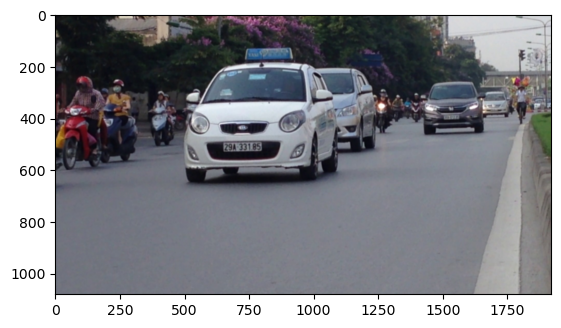

In [59]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

In [60]:
findPlate = PlateFinder(
    minPlateArea=4100,
    maxPlateArea=15000
)

In [61]:
model = OCR(
    modelFile='./saved_models/binary_128_0.50_ver3.pb',
    labelFile='./saved_models/binary_128_0.50_labels_ver2.txt'
)

In [62]:
possible_plates = findPlate.find_possible_plates(img)

license plate number: 29A33185


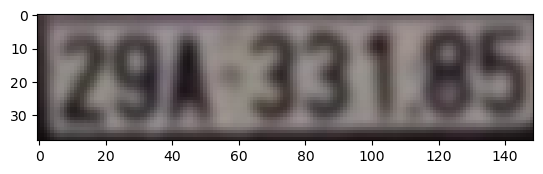

In [63]:
if possible_plates is not None:
    for i, p in enumerate(possible_plates):
        chars_on_plate = findPlate.char_on_plate[i]
        recongnized_plate, _ = model.label_image_list(
            chars_on_plate,
            imageSizeOuput=128
        )
        print('license plate number:', recongnized_plate)
        plt.imshow(p)
else:
    print('License plate number not recognized')